In [2]:
import pandas as pd
import os

In [10]:
os.getcwd() # sprawdzam w jakim katalogu jestem, aby wpisać właściwą ścieżkę do pliku

'C:\\Users\\oldak\\Downloads\\Pandas-Data-Science-Tasks-master\\Pandas-Data-Science-Tasks-master'

In [4]:
os.chdir('..') #metoda do zmiany katalogu '..' oznaczają cofnięcie do katalogu wyżej

Task #1 Merging 12 months of sales date into a single file CSV file

In [3]:
df = pd.read_csv('./SalesAnalysis/Sales_Data/Sales_April_2019.csv')

In [4]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [13]:
os.listdir('./SalesAnalysis/Sales_Data')

['Sales_April_2019.csv',
 'Sales_August_2019.csv',
 'Sales_December_2019.csv',
 'Sales_February_2019.csv',
 'Sales_January_2019.csv',
 'Sales_July_2019.csv',
 'Sales_June_2019.csv',
 'Sales_March_2019.csv',
 'Sales_May_2019.csv',
 'Sales_November_2019.csv',
 'Sales_October_2019.csv',
 'Sales_September_2019.csv']

In [33]:
#files1 = os.listdir('./SalesAnalysis/Sales_Data') - przykład przypisania listy plików, które są w katalogu.
#a Poniżej wersja z list comprehension, które jest
#przydatne jeżeli chcemy odfiltrować pliki do pobrania z folderu
#np. files = [f for f in os.listdir('./SalesAnalysis/Sales_Data') if f.endswith('.csv')]

In [14]:
files = [file for file in os.listdir('SalesAnalysis/Sales_Data')]

In [30]:
all_months_data = pd.DataFrame()

In [31]:
for file in files:
    df = pd.read_csv('SalesAnalysis/Sales_Data/'+file)
    all_months_data = pd.concat([all_months_data, df])


In [34]:
all_months_data.to_csv('all data.csv', index=False)

### Read in updated data

In [7]:
all_data = pd.read_csv('all_data.csv')

In [8]:
all_data.shape

(186850, 6)

### Clean up the data

#### drop rows of nan

In [11]:
nan_df = all_data[all_data.isna().any(axis=1)]
nan_df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1,NaN,NaN,NaN,NaN,NaN,NaN
356,NaN,NaN,NaN,NaN,NaN,NaN
735,NaN,NaN,NaN,NaN,NaN,NaN
1433,NaN,NaN,NaN,NaN,NaN,NaN
1553,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
185176,NaN,NaN,NaN,NaN,NaN,NaN
185438,NaN,NaN,NaN,NaN,NaN,NaN
186042,NaN,NaN,NaN,NaN,NaN,NaN
186548,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
all_data = all_data.dropna(how='all')

In [67]:
all_data.isna().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
dtype: int64

#### Find 'or' and delete it

In [13]:
all_data = all_data[~all_data['Order Date'].str.contains('or', case=False)]

### Convert columns to the correct type

In [33]:
all_data['Price Each'] = pd.to_numeric(all_data['Price Each']) # make float

ValueError: Unable to parse string "Price Each" at position 519

In [15]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])# make int

In [16]:
all_data['Price Each'] = all_data['Price Each'].astype(int)

### Data with additional column

#### Task 2: add month column

In [17]:
all_data['Month'] = all_data['Order Date'].str[:2]

In [104]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",04
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",04


In [18]:
all_data['Month'] = all_data['Month'].astype('int32')

#### Task 3: add a Sales column

In [19]:
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']

In [115]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",04,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",04,11.99


#### Task 3: add a City column

In [20]:
all_data['City'] = all_data['Purchase Address'].str.split(',').str[1]
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City
0,176558,USB-C Charging Cable,2,11,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,22,Dallas
2,176559,Bose SoundSport Headphones,1,99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99,Boston
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600,Los Angeles
4,176560,Wired Headphones,1,11,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11,Los Angeles
5,176561,Wired Headphones,1,11,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11,Los Angeles
...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001",9,6,Los Angeles
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016",9,700,San Francisco
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016",9,700,San Francisco
186848,259356,34in Ultrawide Monitor,1,379,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016",9,379,San Francisco


##### Question 1: What was the best month for sales? How much was earned that month?

In [21]:
results = all_data.groupby('Month')['Sales'].sum()

In [46]:
import matplotlib.pyplot as plt

In [125]:
months = range(1, 13)

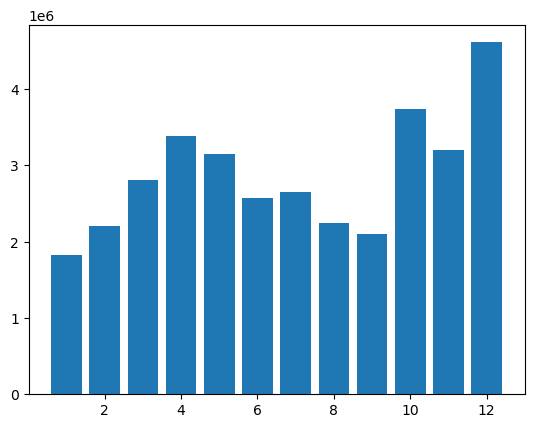

In [132]:
plt.bar(months, results)
plt.show()

##### Question 2: What city had the highest number of sales?

In [22]:
results = all_data.groupby('City')['Sales'].sum()
results

City
Atlanta          2782841
Austin           1811054
Boston           3644327
Dallas           2755117
Los Angeles      5426973
New York City    4642872
Portland         2309717
San Francisco    8223669
Seattle          2735070
Name: Sales, dtype: int64

In [23]:
cities = [city for city, df in all_data.groupby('City')]
cities

[' Atlanta',
 ' Austin',
 ' Boston',
 ' Dallas',
 ' Los Angeles',
 ' New York City',
 ' Portland',
 ' San Francisco',
 ' Seattle']

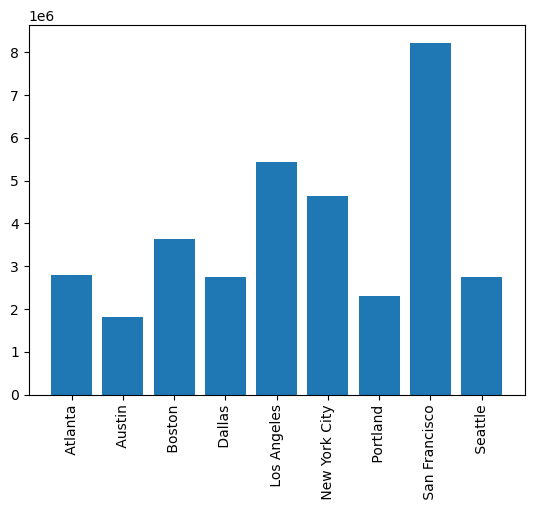

In [76]:
plt.bar(cities, results)
plt.xticks(cities, rotation='vertical')
plt.show()

##### Question 4: What time should we display advertisements to maximize likelihood of customer's buying product?

In [37]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], format='%d%m%Y %H:%M')

In [40]:
all_data['Hour'] = all_data['Order Date'].dt.hour
all_data['Minute'] = all_data['Order Date'].dt.minute

In [43]:
hours = [hour for hour, dt in all_data.groupby('Hour')]

plt.plot(hours, all_data.groupby(['Hour']).count())
plt.xticks(hours)
plt.xlabel('Hour')
plt.ylabel('Number of orders')
plt.grid()
plt.show

##### My recommendation is around 11 or 19

##### Question 4: What products are often sold together?

In [63]:
df = all_data[all_data['Order ID'].duplicated(keep=False)]
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df = df[['Order ID', 'Grouped']].drop_duplicates()
df.head()

,Order ID,Grouped
3,176560,"Google Phone,Wired Headphones"
18,176574,"Google Phone,USB-C Charging Cable"
30,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,"AAA Batteries (4-pack),Google Phone"
119,176672,"Lightning Charging Cable,USB-C Charging Cable"


In [69]:
from itertools import combinations
from collections import Counter

count = Counter()

for row in df['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2)))

for key, value in count.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92
